In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')


# Chargement des données
med  = pd.read_csv('../data/silver/J0_silver_medicaments.csv', low_memory=False) #catalogue médicaments (noms, labo, molécule, code ATC, profils patients)
rup  = pd.read_csv('../data/silver/J0_silver_ruptures.csv',    low_memory=False) #l'historique des ruptures de stocks signalées à l'ANSM 
bdpm = pd.read_csv('../data/silver/J0_silver_bdpm.csv',        low_memory=False)# referentiel officiel de la base de données publiques des médicaments

print(f'Médicaments : {len(med):,} lignes')
print(f'Ruptures    : {len(rup):,} lignes')
print(f'BDPM        : {len(bdpm):,} lignes')



Médicaments : 15,789 lignes
Ruptures    : 12,465 lignes
BDPM        : 7,711 lignes


In [2]:
# Aperçu médicaments
print("=== MEDICAMENTS ===")
print(med.head())
print(med.dtypes)
print(med.isnull().sum())

=== MEDICAMENTS ===
        cis                                     nom_medicament  \
0  61266250                a 313 200 000 ui pour cent, pommade   
1  62869109                   a 313 50 000 u.i., capsule molle   
2  61876780  abacavir arrow 300 mg, comprimé pelliculé sécable   
3  68257528  abacavir/lamivudine accord 600 mg/300 mg, comp...   
4  62828870  abacavir/lamivudine arrow 600 mg/300 mg, compr...   

                laboratoire code_atc                molecule  \
0      pharma developpement    D03AX     AUTRES CICATRISANTS   
1      pharma developpement  A11CA01    Rétinol (vitamine A)   
2          arrow generiques  J05AF06                Abacavir   
3  accord healthcare france  J05AR02  Lamivudine et abacavir   
4          arrow generiques  J05AR02  Lamivudine et abacavir   

   nb_patients_ville                                   substance_active  \
0              300.0  concentrat de vitamine a synthétique, forme hu...   
1            20000.0  concentrat de vitamine a s

In [3]:
# Aperçu ruptures
print("=== RUPTURE ===")
print(rup.head())
print(rup.dtypes)
print(rup.isnull().sum())

=== RUPTURE ===
        cis                                     nom_medicament  \
0  66136969  voriconazole stragen 200 mg, poudre pour solut...   
1  66895877         metformine teva 850 mg, comprimé pelliculé   
2  66895877         metformine teva 850 mg, comprimé pelliculé   
3  66895877         metformine teva 850 mg, comprimé pelliculé   
4  63834189        dasatinib vivanta 50 mg, comprimé pelliculé   

                                            cause classification  \
0  Défaut d'approvisionnement en Matière Première        rupture   
1             Capacité de production insuffisante        rupture   
2             Capacité de production insuffisante        rupture   
3             Capacité de production insuffisante        rupture   
4                               Transfert de site        rupture   

  date_evenement code_atc      molecule  \
0     2021-05-04  J02AC03  Voriconazole   
1     2023-07-20  A10BA02    Metformine   
2     2022-07-15  A10BA02    Metformine   
3     

In [4]:
# Aperçu BDPM
print("=== BDPM ===")
print(bdpm.head())
print(bdpm.dtypes)
print(bdpm.isnull().sum())

=== BDPM ===
        cis      atc                                       denomination  \
0  60003620  R03BA01  BECLOSPIN 800 microgrammes/2ml suspension pour...   
1  60004277  C10AB05                    FENOFIBRATE TEVA 100 mg, gélule   
2  60004487  N02AX02  TRAMADOL EG L.P. 200 mg, comprimé à libération...   
3  60005856  A02BA03            FAMOTIDINE EG 20 mg, comprimé pelliculé   
4  60010166  B05XA03  CHLORURE DE SODIUM PROAMP 0,0585 g/ml (5,85 %)...   

                                                lien  \
0  http://base-donnees-publique.medicaments.gouv....   
1  http://base-donnees-publique.medicaments.gouv....   
2  http://base-donnees-publique.medicaments.gouv....   
3  http://base-donnees-publique.medicaments.gouv....   
4  http://base-donnees-publique.medicaments.gouv....   

                       substance            dosage  est_antihistaminique  
0  DIPROPIONATE DE BÉCLOMÉTASONE  800 microgrammes                 False  
1                    FÉNOFIBRATE         100,00 m

In [5]:
anti_med = med[med['est_antihistaminique'] == 1]
anti_rup = rup[rup['est_antihistaminique'] == 1]
anti_bdpm = bdpm[bdpm['est_antihistaminique'] == True]

print(f'Antihistaminiques médicaments : {len(anti_med)}')
print(f'Antihistaminiques ruptures    : {len(anti_rup)}')
print(f'Antihistaminiques BDPM        : {len(anti_bdpm)}')

Antihistaminiques médicaments : 178
Antihistaminiques ruptures    : 40
Antihistaminiques BDPM        : 15


178 dans médicaments → c'est tous les antihistaminiques qui existent sur le marché français
40 dans ruptures → parmi ces 178, seulement 40 ont connu une rupture de stock entre 2021 et 2024
15 dans BDPM → c'est le référentiel officiel, plus restrictif dans sa classification

In [6]:
print(anti_med['laboratoire'].value_counts().head(10))

laboratoire
biogaran                                        20
arrow generiques                                17
viatris sante                                   16
zentiva france                                  14
eg labo - laboratoires eurogenerics             12
sandoz                                          12
teva sante                                      10
cristers                                         8
zydus france                                     6
menarini international operations luxembourg     6
Name: count, dtype: int64


Ce sont tous des laboratoires de génériques. La majorité des antihistaminiques vendus en France sont des médicaments génériques — pas des médicaments de marque originaux. C'est logique car les molécules comme la cétirizine ou la loratadine sont très anciennes, leurs brevets ont expiré depuis longtemps.

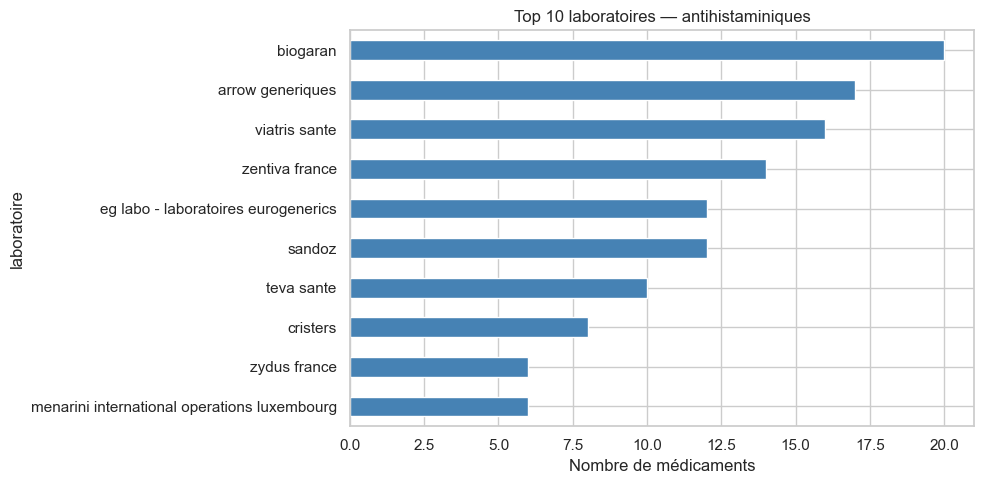

In [7]:
top_labo = anti_med['laboratoire'].value_counts().head(10)

top_labo.plot(kind='barh', figsize=(10, 5), color='steelblue')
plt.title('Top 10 laboratoires — antihistaminiques')
plt.xlabel('Nombre de médicaments')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
age_cols = ['pct_age_0_19_ans', 'pct_age_20_59_ans', 'pct_age_60_ans_et_plus']
age_means = anti_med[age_cols].mean()
print(age_means)

pct_age_0_19_ans          23.078992
pct_age_20_59_ans         50.800142
pct_age_60_ans_et_plus    26.040009
dtype: float64


tranche d'âge active (20-59 ans) 51% =>  exposée à l'extérieur (travail, transports, activités).
Les enfants (0-19 ans) représentent 23% — les allergies pédiatriques sont loin d'être négligeables.

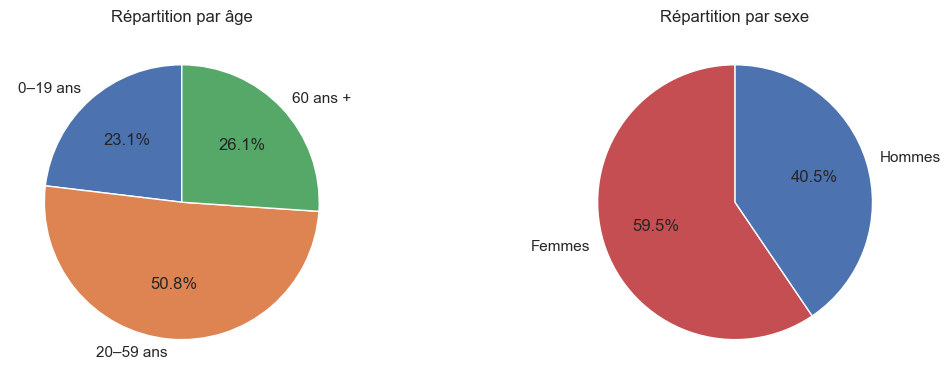

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Âge
age_means.rename({
    'pct_age_0_19_ans':       '0–19 ans',
    'pct_age_20_59_ans':      '20–59 ans',
    'pct_age_60_ans_et_plus': '60 ans +'
}).plot(kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90,
        colors=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Répartition par âge')
axes[0].set_ylabel('')

# Sexe
anti_med[['pct_sexe_female','pct_sexe_male']].mean().rename({
    'pct_sexe_female': 'Femmes',
    'pct_sexe_male':   'Hommes'
}).plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
        colors=['#C44E52','#4C72B0'])
axes[1].set_title('Répartition par sexe')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [11]:
print(anti_rup.groupby('annee').size())

annee
2021     9
2022    17
2023    10
2024     4
dtype: int64


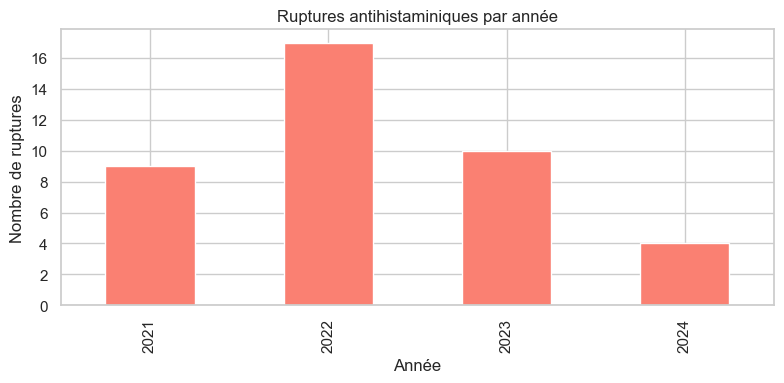

In [12]:
anti_rup.groupby('annee').size().plot(kind='bar', figsize=(8, 4), color='salmon')
plt.title('Ruptures antihistaminiques par année')
plt.xlabel('Année')
plt.ylabel('Nombre de ruptures')
plt.tight_layout()
plt.show()

In [13]:
print(anti_rup['saison_allergies'].value_counts().rename({1: 'Saison allergique', 0: 'Hors saison'}))

saison_allergies
Hors saison          30
Saison allergique    10
Name: count, dtype: int64


Les laboratoires anticipent la saison allergique. Ils produisent et stockent avant la saison (donc hors saison). C'est pendant cette phase de préparation que les problèmes surviennent :

- Manque de matière première
- Capacité de production insuffisante
- Transfert de site de fabrication

Du coup les ruptures se déclarent avant que la demande explose, pas pendant.

In [14]:
print(anti_rup['molecule'].value_counts().head(10))

molecule
Desloratadine          9
Oxomémazine            9
Cétirizine             4
Bilastine              4
Dexchlorphéniramine    4
Doxylamine             3
Ebastine               3
Lévocétirizine         2
Rupatadine             1
Loratadine             1
Name: count, dtype: int64


Desloratadine + Oxomémazine => molécules très prescrites donc très demandées, ce qui crée une pression sur l'approvisionnement

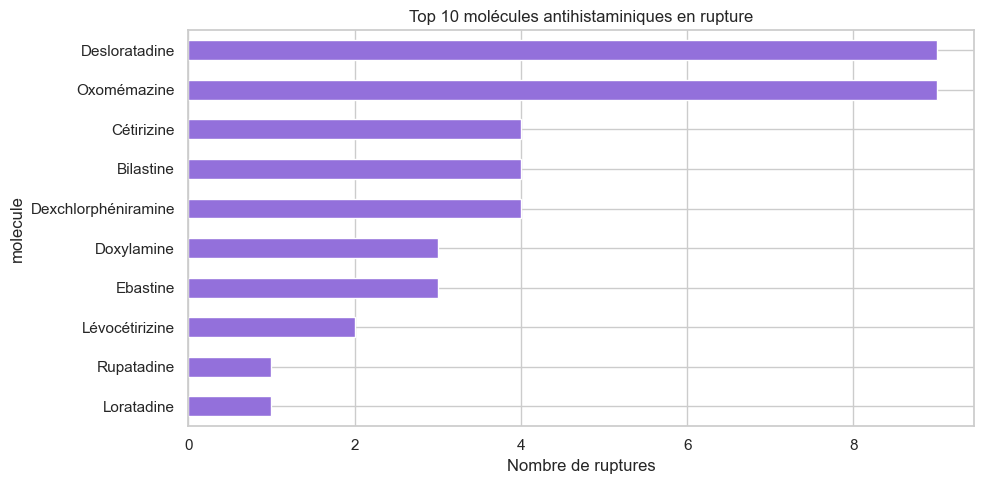

In [15]:
anti_rup['molecule'].value_counts().head(10).plot(kind='barh', figsize=(10, 5), color='mediumpurple')
plt.title('Top 10 molécules antihistaminiques en rupture')
plt.xlabel('Nombre de ruptures')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

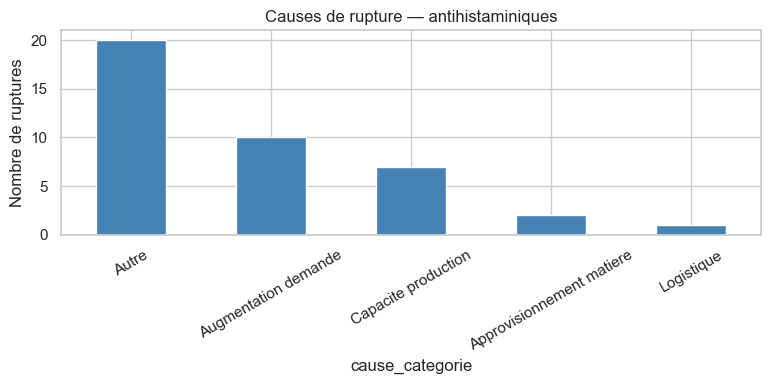

In [16]:
anti_rup['cause_categorie'].value_counts().plot(kind='bar', figsize=(8, 4), color='steelblue', rot=30)
plt.title('Causes de rupture — antihistaminiques')
plt.ylabel('Nombre de ruptures')
plt.tight_layout()
plt.show()

In [17]:
jointure = anti_med.merge(anti_rup, on='cis', how='inner')
print(jointure.shape)
print(jointure[['nom_medicament_x', 'molecule_x', 'nb_patients_ville_x', 'annee', 'cause_categorie']].head(10))

(40, 27)
                                    nom_medicament_x     molecule_x  \
0                     bilastine teva 20 mg, comprimé      Bilastine   
1                     bilastine teva 20 mg, comprimé      Bilastine   
2                     bilastine teva 20 mg, comprimé      Bilastine   
3                  bilastine zentiva 20 mg, comprimé      Bilastine   
4  cetirizine almus 10 mg, comprimé pelliculé séc...     Cétirizine   
5  cetirizine almus 10 mg, comprimé pelliculé séc...     Cétirizine   
6  cetirizine almus 10 mg, comprimé pelliculé séc...     Cétirizine   
7  cetirizine evolugen 10 mg, comprimé pelliculé ...     Cétirizine   
8       desloratadine almus 5 mg, comprimé pelliculé  Desloratadine   
9       desloratadine almus 5 mg, comprimé pelliculé  Desloratadine   

   nb_patients_ville_x  annee            cause_categorie  
0             100000.0   2022  Approvisionnement matiere  
1             100000.0   2023       Augmentation demande  
2             100000.0   2023   

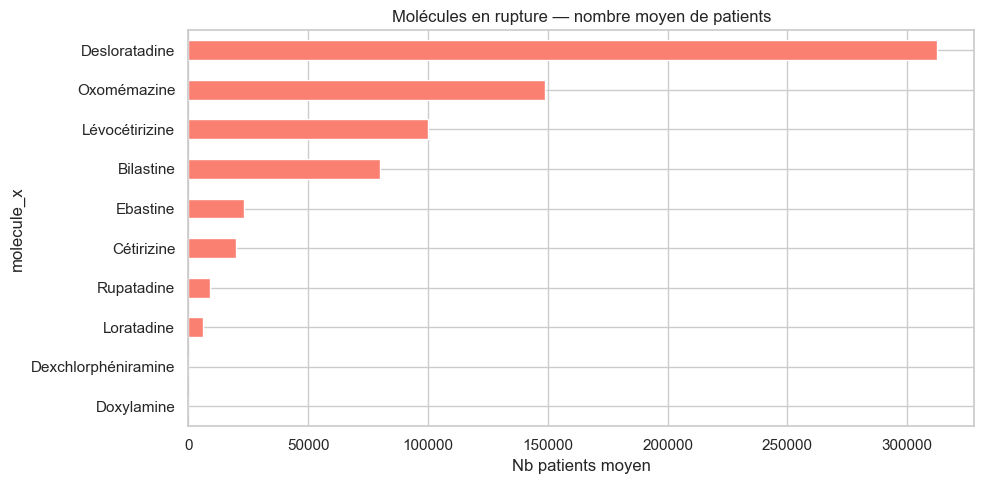

In [18]:
top_ruptures = jointure.groupby('molecule_x')['nb_patients_ville_x'].mean().sort_values(ascending=False).head(10)

top_ruptures.plot(kind='barh', figsize=(10, 5), color='salmon')
plt.title('Molécules en rupture — nombre moyen de patients')
plt.xlabel('Nb patients moyen')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Peu de patients = peu produits = stock très faible = la moindre perturbation dans la chaîne d'approvisionnement suffit à créer une rupture.
C'est l'effet inverse de la Desloratadine — les deux extrêmes sont vulnérables aux ruptures mais pour des raisons opposées :

Desloratadine → trop demandée
Dexchlorphéniramine/Doxylamine → trop peu produite

Dans le contexte des ruptures de médicaments, "Autre" peut recouvrir plein de choses :

Problèmes réglementaires — un lot refusé par l'ANSM pour non-conformité
Arrêt volontaire — le laboratoire décide d'arrêter commercialiser le médicament
Problème qualité — rappel de lot, contamination
Force majeure — incendie d'usine, catastrophe naturelle (ex: l'usine Fareva en 2022)
Problèmes informatiques — système de commande défaillant
Faillite d'un sous-traitant — un fournisseur de packaging ou de principe actif qui disparaît

Le fait que "Autre" soit la catégorie dominante (20 ruptures) montre que les causes sont souvent complexes ou multifactorielles — difficiles à classer dans une seule catégorie propre.

## Conclusions — EDA Médicaments & Ruptures ANSM

### 1. Périmètre des antihistaminiques
- 178 antihistaminiques recensés sur le marché français
- Seulement 40 ont connu au moins une rupture de stock entre 2021 et 2024
- Le référentiel BDPM en liste 15 — plus restrictif dans sa classification

### 2. Un marché dominé par les génériques
La quasi-totalité des laboratoires producteurs sont des spécialistes du générique (Biogaran, Arrow, Teva, Sandoz...). C'est logique : les molécules antihistaminiques comme la cétirizine ou la loratadine sont anciennes et leurs brevets ont expiré depuis longtemps.

### 3. Profil des patients
- La tranche 20-59 ans représente 51% des patients — population active, exposée à l'extérieur
- Les enfants (0-19 ans) représentent 23% — les allergies pédiatriques sont significatives
- Les femmes sont plus touchées que les hommes (60% vs 40%)

### 4. Saisonnalité paradoxale des ruptures
Contre-intuitivement, les ruptures surviennent majoritairement **hors saison allergique**. Les laboratoires anticipent la demande et produisent avant la saison — c'est pendant cette phase de préparation que les problèmes d'approvisionnement se déclarent.

### 5. Molécules à risque
Deux profils opposés de vulnérabilité :
- **Trop demandées** : Desloratadine (300 000+ patients) et Oxomémazine — la pression de la demande crée des tensions
- **Trop peu produites** : Dexchlorphéniramine et Doxylamine — un stock faible suffit à provoquer une rupture

### 6. Causes de rupture
La catégorie "Autre" domine (20 ruptures sur 40), ce qui reflète la complexité et le caractère multifactoriel des ruptures. Parmi les causes identifiées, l'augmentation de la demande est la principale, suivie des problèmes de capacité de production.